### Simulação de Efeitos de Tratamento heterogêneos

In [131]:
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

import statsmodels.api as sm
from pyfixest.estimation import feols
import pyfixest as pf

# CS ML
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

In [132]:
# === Etapa 1: Carregar shapefile dos municípios do Brasil ===
shapefile_path = "C:/Users/danie/OneDrive/Área de Trabalho/BR_Municipios_2024.shp"
gdf = gpd.read_file(shapefile_path)

# Selecionar e renomear colunas principais
gdf = gdf[['CD_MUN', 'NM_MUN', 'SIGLA_UF', 'geometry']].copy()
gdf = gdf.rename(columns={'CD_MUN': 'codmun', 'NM_MUN': 'municipio', 'SIGLA_UF': 'uf'})

# Calcular centroides
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

# === Etapa 2: Simular covariáveis iniciais e suas tendências ===
np.random.seed(42)
n_mun = gdf.shape[0]
gdf['X1'] = np.random.normal(0, 1, n_mun)
gdf['X2'] = np.random.normal(0, 1, n_mun)
gdf['X3'] = np.random.normal(0, 1, n_mun)

# Tendência de crescimento heterogênea
gdf['X1_trend'] = np.random.normal(0.01, 0.005, n_mun)
gdf['X2_trend'] = np.random.normal(0.02, 0.007, n_mun)
gdf['X3_trend'] = np.random.normal(0.015, 0.004, n_mun)

# === Etapa 3: Expandir painel 2000–2024 com evolução dos X ===
years = list(range(2000, 2025))
panel = pd.DataFrame(
    [(row.codmun, row.municipio, row.uf,
      row.X1 + (year - 2000) * row.X1_trend,
      row.X2 + (year - 2000) * row.X2_trend,
      row.X3 + (year - 2000) * row.X3_trend,
      row.lat, row.lon, year)
     for idx, row in gdf.iterrows() for year in years],
    columns=['codmun', 'municipio', 'uf', 'X1', 'X2', 'X3', 'lat', 'lon', 'year']
)

# === Etapa 4: Atribuir tratamento a 10% dos municípios (7% via características, 3% aleatório) ===
np.random.seed(42)

# Passo 1: calcular escore de propensão ao tratamento
gdf['prop_score'] = 1 / (1 + np.exp(-(1.5 * gdf['X1'] + 1.0 * gdf['X2'] + 0.5 * gdf['X3'])))

# Passo 2: ordenar por escore e selecionar top 7%
n_7 = int(0.07 * n_mun)
treated_by_score = gdf.sort_values(by='prop_score', ascending=False).head(n_7)['codmun'].tolist()

# Passo 3: selecionar 3% aleatoriamente entre os restantes
remaining = gdf[~gdf['codmun'].isin(treated_by_score)]
n_3 = int(0.03 * n_mun)
treated_random = np.random.choice(remaining['codmun'], size=n_3, replace=False).tolist()

# Passo 4: juntar tratados
treated_muns = treated_by_score + treated_random
gdf['treated'] = gdf['codmun'].isin(treated_muns).astype(int)

# Passo 5: definir anos de tratamento entre 2005 e 2020
treatment_years = {mun: np.random.randint(2005, 2021) for mun in treated_muns}
panel['treat_year'] = panel['codmun'].map(treatment_years)
panel['D'] = ((panel['treat_year'].notnull()) & (panel['year'] >= panel['treat_year'])).astype(int)

# Calcular anos desde tratamento (efeito dinâmico)
panel['years_treated'] = (panel['year'] - panel['treat_year']).clip(lower=0)
panel['years_treated'] = panel['years_treated'].where(panel['D'] == 1, 0)
panel['treatment_effect'] = panel['years_treated'].clip(upper=3)

# === Etapa 5: Matriz de vizinhança espacial ===
w = Queen.from_dataframe(gdf)
W_sparse = w.full()[0]

# === Etapa 6: Recalcular índice socioeconômico por ano (com interações complexas) ===
panel['X_index'] = 0.0
for year in years:
    df_year = panel.loc[panel['year'] == year, ['X1', 'X2', 'X3']]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_year)
    X1s, X2s, X3s = X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2]
    
    X_index_new = (
        0.5 * (X1s + X2s + X3s) +
        0.3 * (X1s * X2s) +
        0.2 * (X1s**2 * X2s * X3s)
    )
    panel.loc[panel['year'] == year, 'X_index'] = X_index_new

# === Etapa 7: Calcular spillover espacial ===
panel['spillover'] = 0.0
for year in years:
    Dt = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(Dt['D']).fillna(0).values.reshape(-1, 1)
    spill_raw = W_sparse @ D_vector
    spill_strength = spill_raw.flatten() * panel.loc[panel['year'] == year, 'X_index'].values
    panel.loc[panel['year'] == year, 'spillover'] = spill_strength

# === Etapa 8: Gerar variável de resultado Y ===
np.random.seed(42)
panel['alpha_i'] = panel['codmun'].astype('category').cat.codes * 0.02
panel['lambda_t'] = (panel['year'] - 2000) * 0.01
panel['epsilon'] = np.random.normal(0, 0.3, panel.shape[0])

# Coeficientes de impacto
beta = 1.5  # efeito direto
gamma = 0.8  # efeito spillover

panel['Y'] = (
    2 +
    0.6 * panel['X1'] +
    0.4 * panel['X2'] +
    0.2 * panel['X3'] +
    beta * panel['treatment_effect'] +
    gamma * panel['spillover'] +
    panel['alpha_i'] +
    panel['lambda_t'] +
    panel['epsilon']
)

Visualizando o mapa do Brasil com os municípios que foram tratados e não tratados.

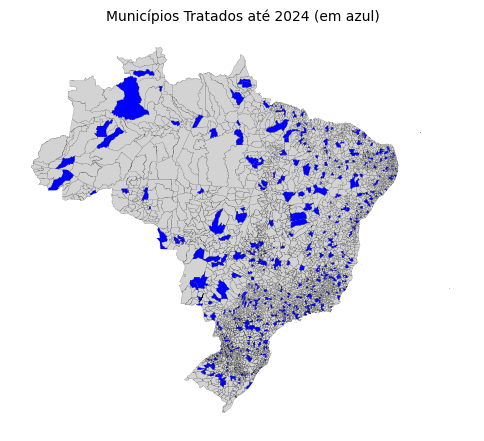

In [133]:
# Filtra apenas o último ano (2024)
panel_2024 = panel[panel['year'] == 2024]

# Junta com o GeoDataFrame para obter as geometrias
mapa_2024 = gdf.merge(panel_2024[['codmun', 'D']], on='codmun', how='left')

# Plota o mapa: municípios tratados (D=1) em azul, os demais em cinza claro
fig, ax = plt.subplots(figsize=(6, 7))
mapa_2024[mapa_2024['D'] == 0].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
mapa_2024[mapa_2024['D'] == 1].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados até 2024 (em azul)', fontsize=10)
ax.axis('off')
plt.show()


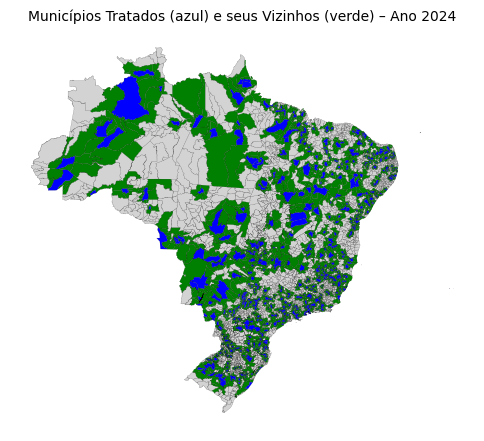

In [112]:
# 1. Filtra ano de 2024
panel_2024 = panel[panel['year'] == 2024]

# 2. Municípios tratados até 2024
treated_muns = set(panel_2024.loc[panel_2024['D'] == 1, 'codmun'])

# 3. Identifica vizinhos dos tratados
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# Coleta todos os vizinhos dos tratados
vizinhos = set()
for mun in treated_muns:
    idx = codmun_to_index.get(mun)
    if idx is not None:
        vizinhos.update([index_to_codmun[i] for i in neighbors_dict.get(idx, [])])

# Remove os próprios tratados da lista de vizinhos
vizinhos = vizinhos - treated_muns

# 4. Classificação para visualização
gdf['status'] = 'Não tratado'
gdf.loc[gdf['codmun'].isin(vizinhos), 'status'] = 'Vizinho tratado'
gdf.loc[gdf['codmun'].isin(treated_muns), 'status'] = 'Tratado'

# 5. Mapa com 3 cores
fig, ax = plt.subplots(figsize=(6, 7))
gdf[gdf['status'] == 'Não tratado'].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Vizinho tratado'].plot(ax=ax, color='green', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Tratado'].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados (azul) e seus Vizinhos (verde) – Ano 2024', fontsize=10)
ax.axis('off')
plt.show()


Filtragem adicional da base

* vizinho de tratado
* ano que esse vizinho foi "tratado"
* grupo de tratados
* grupo de vizinhos tratados
* nunca tratados


Adiciona o uma variável de efeito espacial do tratamento (1 para os vizinhos dos municípios tratados, 0 caso contrário).

In [134]:
# Inicializa a coluna WD no panel
panel['WD'] = 0.0

# Calcula WD ano a ano (importante manter a ordem correta dos municípios)
for year in years:
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # respeita a ordem do gdf
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()

In [135]:
# 1. Obter os municípios tratados (independente do ano)
treated_codmuns = gdf[gdf['treated'] == 1]['codmun'].tolist()

# 2. Construir o dicionário de vizinhos (índice → codmun)
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# 3. Coletar todos os vizinhos dos tratados
vizinhos_tratados = set()
for mun in treated_codmuns:
    idx = codmun_to_index.get(mun)
    vizinhos_idx = neighbors_dict.get(idx, [])
    vizinhos_cod = [index_to_codmun[i] for i in vizinhos_idx]
    vizinhos_tratados.update(vizinhos_cod)

# 4. Remover os próprios tratados (só queremos vizinhos puros)
vizinhos_tratados -= set(treated_codmuns)

# 5. Criar a variável indicadora no painel
panel['is_neighbor_of_treated'] = panel['codmun'].isin(vizinhos_tratados).astype(int)

In [136]:
# 1. Dicionário com o ano de tratamento de cada município
treat_year_dict = panel[['codmun', 'treat_year']].dropna().drop_duplicates().set_index('codmun')['treat_year'].to_dict()

# 2. Dicionário de vizinhos: codmun → lista de codmuns vizinhos
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}
codmun_neighbors = {
    codmun: [index_to_codmun[i] for i in neighbors_dict.get(codmun_to_index[codmun], [])]
    for codmun in gdf['codmun']
}

# 3. Função para obter o menor ano de tratamento entre os vizinhos
def get_earliest_neighbor_treat_year(codmun, year):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict and treat_year_dict[v] <= year]
    return min(anos_tratamento) if anos_tratamento else None

# 4. Criar a nova variável no panel
panel['g_neighbor_of_treated_a'] = panel.apply(
    lambda row: get_earliest_neighbor_treat_year(row['codmun'], row['year']),
    axis=1
)

In [137]:
# Versão ESTÁTICA: menor ano de tratamento dos vizinhos, mesmo que ainda não tenha ocorrido
def get_min_neighbor_treat_year(codmun):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict]
    return min(anos_tratamento) if anos_tratamento else None

# Criar coluna fixa no gdf
gdf['g_neighbor_of_treated'] = gdf['codmun'].apply(get_min_neighbor_treat_year)

# Juntar com panel
panel = panel.merge(gdf[['codmun', 'g_neighbor_of_treated']], on='codmun', how='left')

In [138]:
# Criar coluna 'treated' para indicar se o município foi tratado (1) ou não (0), se treat_year > 0
panel['treated'] = (panel['treat_year'] > 0).astype(int)
# Criar coluna 'neighbor_of_treated' para indicar se o município foi tratado (1) ou não (0), se g_neighbor_of_treated > 0
panel['neighbor_of_treated'] = (panel['g_neighbor_of_treated'] > 0).astype(int)
# nunca tratados: aqueles que não foram tratados nem são vizinhos de tratados
panel['never_treated'] = ((panel['treated'] == 0) & (panel['neighbor_of_treated'] == 0)).astype(int)

In [139]:
panel['g_treated'] = panel['treat_year'].where(panel['treated'] == 1, np.nan)
panel['g_neighbor'] = panel['g_neighbor_of_treated'].where(panel['neighbor_of_treated'] == 1, np.nan)

In [140]:
# treated e never treated panel (efeitos diretos)
panel_de = panel[(panel['treated'] == 1) | (panel['never_treated'] == 1)].copy()
# neighbor of treated e never treated panel (efeitos indiretos, excluindo tratados diretos)
panel_id = panel[((panel['neighbor_of_treated'] == 1) & (panel['treated'] == 0)) | (panel['never_treated'] == 1)].copy()

### Verificando modelos em busca do efeito do tratamento

In [141]:
# Regressão linear simples: Y ~ D
df_reg = panel.copy()

X = sm.add_constant(df_reg['D'])  # adiciona intercepto
y = df_reg['Y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     359.3
Date:                qui, 03 jul 2025   Prob (F-statistic):           5.07e-80
Time:                        15:04:24   Log-Likelihood:            -6.8142e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139323   BIC:                         1.363e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.0462      0.088    656.398      0.0

In [142]:
X = sm.add_constant(df_reg[['D', 'X1', 'X2', 'X3']])  # adiciona intercepto
y = df_reg['Y']

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     117.6
Date:                qui, 03 jul 2025   Prob (F-statistic):          2.40e-100
Time:                        15:04:27   Log-Likelihood:            -6.8137e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139320   BIC:                         1.363e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.9284      0.091    634.078      0.0

#### TWFE

In [22]:
twfe_model = feols("Y ~ D | year + codmun", data=panel)
print(twfe_model.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.720 |        0.180 |    20.618 |      0.000 |  3.348 |   4.093 |
---
RMSE: 0.493 R2: 1.0 R2 Within: 0.534 
None


In [23]:
twfe_model2 = feols("Y ~ D + X1 + X2 + X3| year + codmun", data=panel)
print(twfe_model2.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.716 |        0.180 |    20.628 |      0.000 |  3.345 |   4.088 |
| X1            |      0.821 |        0.035 |    23.212 |      0.000 |  0.748 |   0.894 |
| X2            |      0.484 |        0.017 |    29.127 |      0.000 |  0.450 |   0.518 |
| X3            |      0.223 |        0.032 |     7.047 |      0.000 |  0.158 |   0.288 |
---
RMSE: 0.491 R2: 1.0 R2 Within: 0.537 
None


### Diferença em Diferença Espacial (Spatial DiD) conforme Delgado e Florax (2015)

O modelo clássico a ser estimado é:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \epsilon_{it} $$

Ou seja, precisamos:

- Y: resultado
- D: variável de tratamento
- WD: spillover espacial, que precisa ser calculado com base na vizinhança espacial (matriz W) e a variável D
- Efeitos fixos: município (codmun) e tempo (year)


In [143]:
# Converte para categoria para gerar dummies automaticamente
panel['codmun'] = panel['codmun'].astype('category')
panel['year'] = panel['year'].astype('category')

In [ ]:
# Regressão com efeitos fixos + D + WD
model_DD_wd = smf.ols('Y ~ D + WD + C(codmun) + C(year)', data=panel)
results_DD_wd = model_DD_wd.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município
print(results_DD_wd.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.162e+17
Date:                qui, 03 jul 2025   Prob (F-statistic):               0.00
Time:                        10:39:31   Log-Likelihood:                -81215.
No. Observations:              139325   AIC:                         1.736e+05
Df Residuals:                  133726   BIC:                         2.287e+05
Df Model:                        5598                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.7252 

Adicionando covariáveis:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \delta X_{it} + \epsilon_{it} $$


In [ ]:
# Regressão com efeitos fixos e covariáveis: + D + WD + X1 + X2 + X3
model2_DD_wd = smf.ols('Y ~ D + WD + C(codmun) + C(year) + X1 + X2 + X3', data=panel)
results2_DD_wd = model2_DD_wd.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município
print(results2_DD_wd.summary())

c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5601, but rank is 29
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.612e+14
Date:                qua, 02 jul 2025   Prob (F-statistic):               0.00
Time:                        17:03:12   Log-Likelihood:            -1.6065e+05
No. Observations:              139325   AIC:                         3.325e+05
Df Residuals:                  133723   BIC:                         3.876e+05
Df Model:                        5601                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.7605 

#### Gardner (2022)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Gardner (2022).

O modelo de Gardner (2022) está estimando o efeito médio do tratamento sobre os tratados (ATT), de forma agregada ou média, controlando por efeitos fixos e covariáveis (se houver), mas corrigindo um problema comum nas abordagens tradicionais baseadas em dois estágios (two-way fixed effects - TWFE): viés de composição causado por comparação entre grupos tratados em momentos diferentes.

* Ele evita o viés de comparação entre grupos tratados em momentos diferentes, porque o segundo estágio utiliza apenas a variação do tratamento ao longo do tempo, após controlar para efeitos fixos e covariáveis.
* Ao não incluir diretamente os efeitos fixos na segunda regressão, ele evita problemas de colinearidade e viés de composição que afetam o modelo TWFE tradicional.

**Primeiro Estágio: Remoção de efeitos fixos e covariáveis**

Neste passo, estima-se uma regressão linear do desfecho sobre covariáveis e efeitos fixos de unidade e tempo:
 
$$
Y_{it} = X_{it}'\beta + \gamma_i + \delta_t + \epsilon_{it}
$$
 
Onde:  
- $\gamma_i$ representa o efeito fixo da unidade,  
- $\delta_t$ representa o efeito fixo de tempo,  
- $X_{it}$ são as covariáveis.
 
Após essa regressão, obtêm-se os **resíduos ajustados**:

$$
\tilde{Y}_{it} = Y_{it} - \hat{X}_{it}'\hat{\beta} - \hat{\gamma}_i - \hat{\delta}_t
$$
 
**Segundo Estágio: Estimação do efeito do tratamento**
 
Regressa-se o resíduo $\tilde{Y}_{it}$ apenas na variável de tratamento $D_{it}$ (por exemplo, uma dummy indicando o período pós-tratamento):

$$
\tilde{Y}_{it} = \theta \cdot D_{it} + u_{it}
$$

O coeficiente $\theta$ obtido dessa regressão representa a **estimativa do efeito médio do tratamento sobre os tratados (ATT)**.

In [144]:
# Estima o modelo de Gardner (did2s) com covariáveis
fit_gardner = pf.did2s(
    data=panel,
    yname="Y",                     # variável dependente
    treatment="D",                # dummy de tratamento
    first_stage="~ X1 + X2 + X3 | codmun + year",  # controles + efeitos fixos
    second_stage="~ D",           # variável de interesse
    cluster="codmun"              # erro padrão clusterizado
)
print(fit_gardner.summary())

###

Estimation:  DID2S
Dep. var.: Y_hat, Fixed effects: 0
Inference:  CRV1 (GMM)
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.889 |        0.025 |   154.032 |      0.000 |  3.840 |   3.939 |
---
RMSE: 0.501 R2: 0.735 
None


#### Callaway & Sant'Anna (2021)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Callaway e Sant'Anna (2021).


Precisamos ajustar a base para que o estimador funcione corretamente.

In [146]:
panel.loc[panel['g_treated'] == 0, 'g_treated'] = np.inf

panel['g_treated'] = panel['g_treated'].astype(float)
panel['year'] = panel['year'].astype(int)

panel['g_treated'] = panel['g_treated'].fillna(np.inf)

panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

Identificando a base de dados para utilizar com o modelo de ML.

In [147]:
dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['g_treated']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139325 entries, 0 to 139324
Columns: 28 entries, codmun to g_neighbor
dtypes: category(1), float64(19), int64(6), object(2)
memory usage: 29.1+ MB



Rodando o modelo.

In [45]:
dml_obj = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj.fit()
print(dml_obj.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001) -0.0728   0.0732  -0.9936  0.3204 -0.2163  0.0708
ATT(2005.0,2001,2002)  0.1519   0.0786   1.9319  0.0534 -0.0022  0.3061
ATT(2005.0,2002,2003) -0.1718   0.0758  -2.2660  0.0234 -0.3205 -0.0232
ATT(2005.0,2003,2004)  0.0613   0.0867   0.7074  0.4793 -0.1085  0.2312
ATT(2005.0,2004,2005)  0.1613   0.0688   2.3450  0.0190  0.0265  0.2961
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.0031   0.0632   0.0483  0.9614 -0.1209  0.1270
ATT(2020.0,2019,2021)  1.5216   0.0632  24.0566  0.0000  1.3976  1.6455
ATT(2020.0,2019,2022)  3.0991   0.0603  51.3748  0.0000  2.9809  3.2174
ATT(2020.0,2019,2023)  4.4520   0.0494  90.0613  0.0000  4.3551  4.5489
ATT(2020.0,2019,2024)  4.5938   0.0639  71.9462  0.0000  4.4687  4.7190

[384 rows x 6 columns]


Criando os ICs.

In [46]:
level = 0.95

ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.348666  0.203139
ATT(2005.0,2001,2002) -0.144368  0.448253
ATT(2005.0,2002,2003) -0.457519  0.113854
ATT(2005.0,2003,2004) -0.265188  0.387803
ATT(2005.0,2004,2005) -0.097849  0.420467
...                         ...       ...
ATT(2020.0,2019,2020) -0.235145  0.241258
ATT(2020.0,2019,2021)  1.283269  1.759854
ATT(2020.0,2019,2022)  2.871877  3.326421
ATT(2020.0,2019,2023)  4.265749  4.638226
ATT(2020.0,2019,2024)  4.353269  4.834386

[384 rows x 2 columns]


Plotando os resultados.

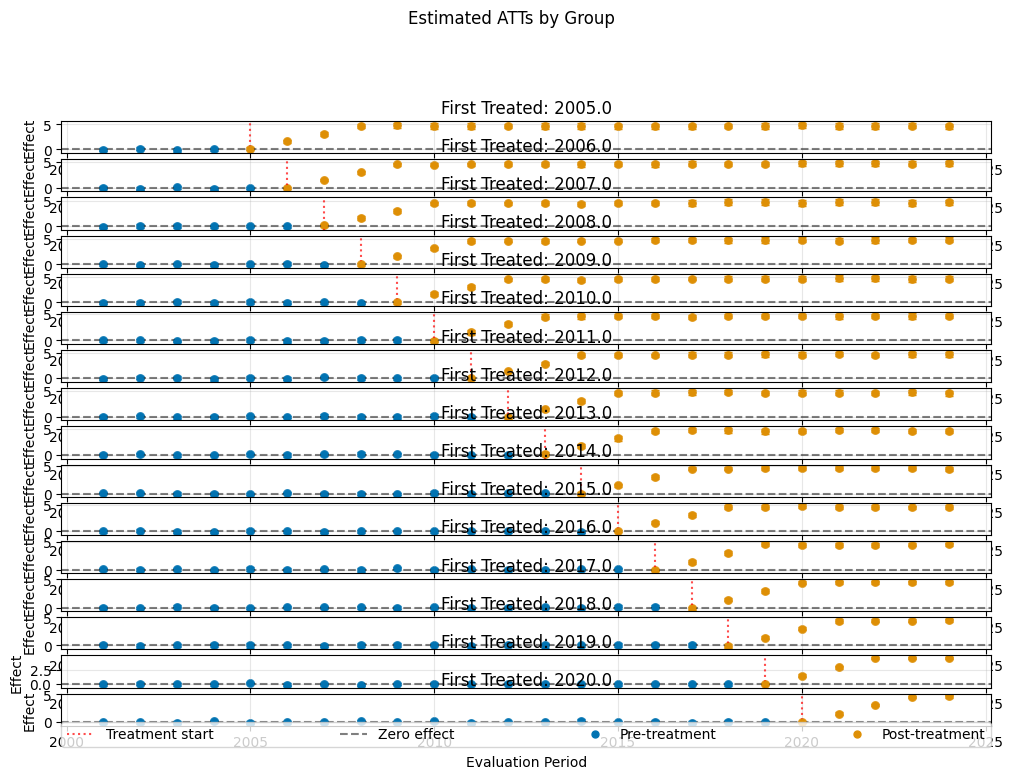

In [47]:
fig, ax = dml_obj.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.172163 0.031598 132.039201    0.0 4.110232 4.234094
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.051015  0.070757   -0.720995  0.470913 -0.189696  0.087665
-18.0 -0.033001  0.050233   -0.656966  0.511203 -0.131456  0.065453
-17.0  0.015182  0.039443    0.384922  0.700295 -0.062124  0.092489
-16.0  0.003422  0.032897    0.104023  0.917151 -0.061056  0.067900
-15.0 -0.034925  0.028086   -1.243494  0.213686 -0.089973  0.020123
-14.0  0.049557  0.028551    1.735700  0.082617 -0.006403  0.105516
-13.0 -0.003855  0.026902   -0.143311  0.886045 -0.056582  0.048871
-12.0 -0.001766  0.022435   -0.078737  0.937242 -0.045737  0.042204
-11.0  0.002722  0.023779    0.114457  0.908876 -0.0438

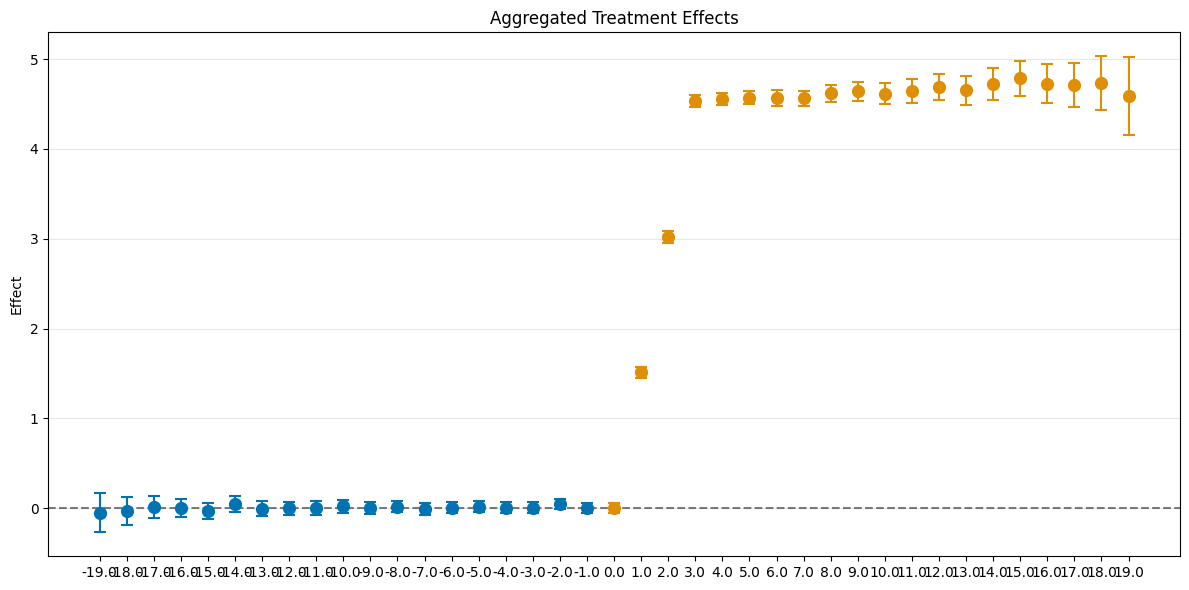

In [48]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj.bootstrap(n_rep_boot=5000)
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy)
fig, ax = aggregated_eventstudy.plot_effects()

In [73]:
aggregated_eventstudy.aggregation_weights[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

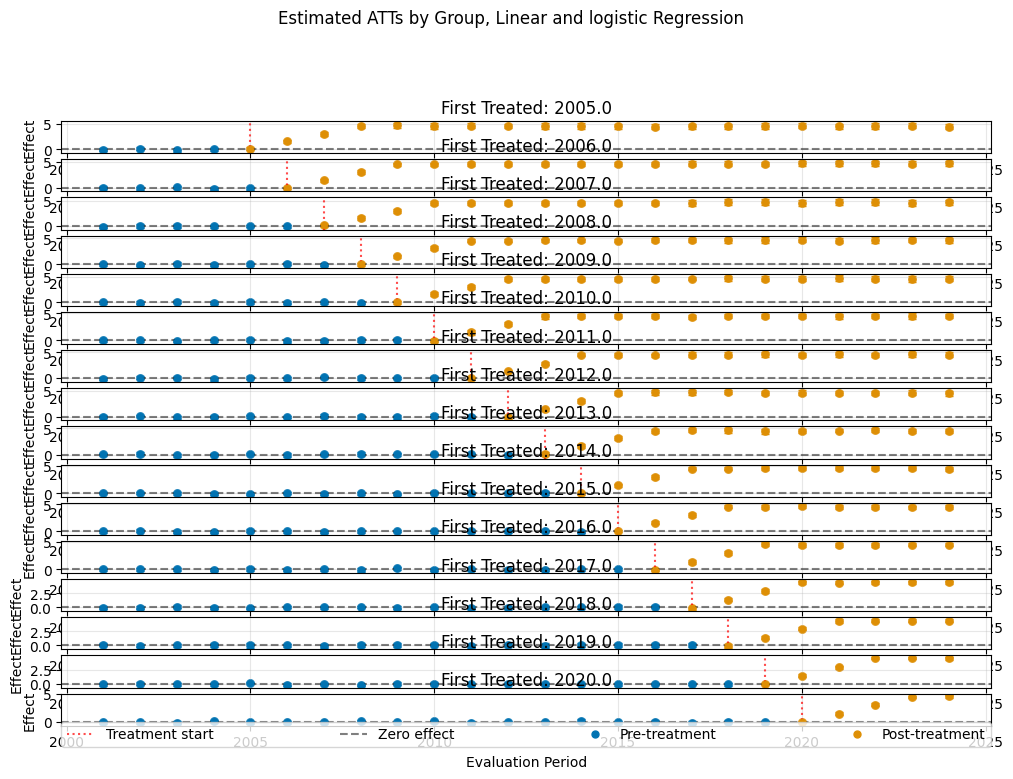

In [74]:
dml_obj_linear_logistic = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_linear_logistic.fit()
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
dml_obj_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

In [75]:
print(dml_obj_linear_logistic)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['treat_year']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LinearRegression()
Learner ml_m: LogisticRegression(penalty=None)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.42477397 0.41788622 0.42178689 0.42355061 0.43803193 0.45200062
  0.46427208 0.48604315 0.50291977 0.51552071 0.5286533  0.53720373
  0.54874513 0.57011053 0.57992224 0.59330116 0.61091315 0.61916922
  0.62351744 0.6483461  0.64772133 0.64824111 0.64754164 0.64328571
  0.42486095 0.41786841 0.4217441  0.42348307 0.43794613 0.45113689
  0.46988111 0.48489513 

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, Linear and logistic Regression'}, ylabel='Effect'>)

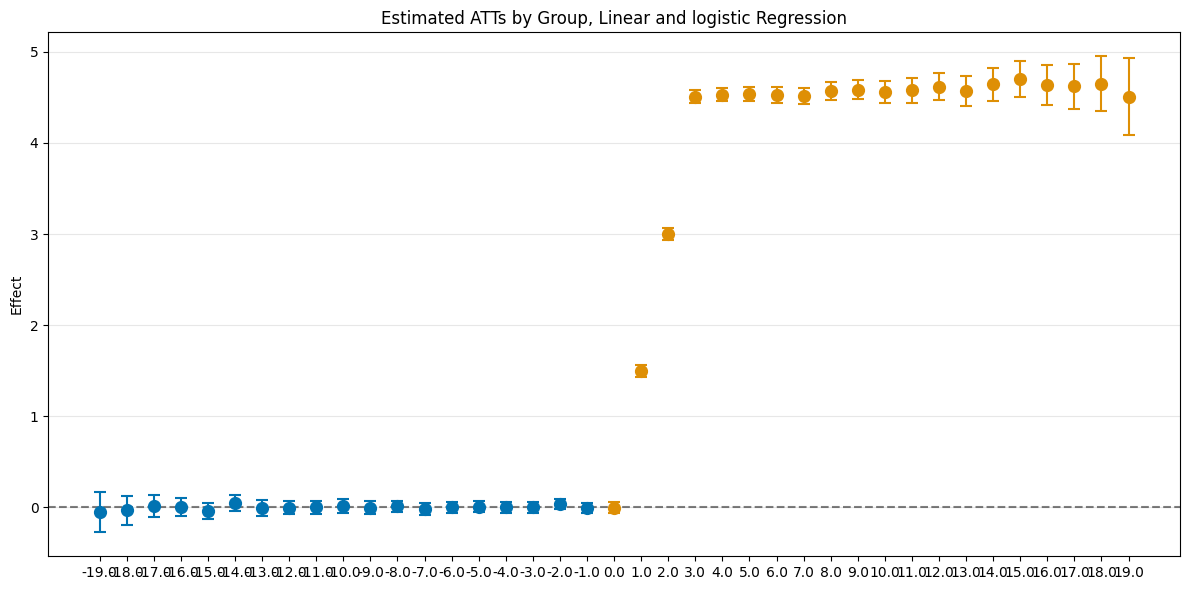

In [76]:
es_linear_logistic = dml_obj_linear_logistic.aggregate("eventstudy")
es_linear_logistic.aggregated_frameworks.bootstrap()
es_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

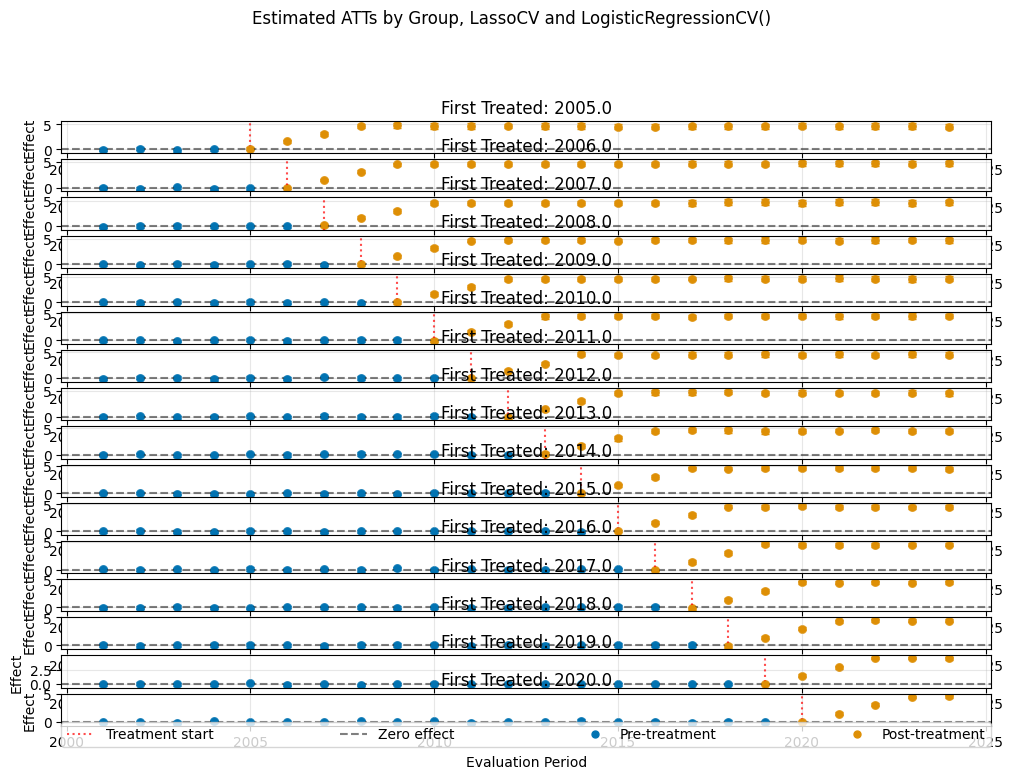

In [77]:
dml_obj_lasso = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LassoCV(),
    ml_m=LogisticRegressionCV(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_lasso.fit()
dml_obj_lasso.bootstrap(n_rep_boot=5000)
dml_obj_lasso.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")

In [38]:
# Model summary
print(dml_obj_lasso)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['treat_year']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LassoCV()
Learner ml_m: LogisticRegressionCV()
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.42446    0.4175359  0.42032397 0.42627319 0.49609952 0.55280643
  0.59676258 0.66020045 0.68172684 0.72551448 0.76728836 0.78854189
  0.82481607 0.85174565 0.89233017 0.92246955 0.93564956 0.95699657
  0.97743884 1.02210825 1.00698373 1.00972461 1.00795358 1.00349414
  0.4243572  0.41742668 0.42021043 0.42635127 0.49637469 0.49866183
  0.55563508 0.61592561 0.65126531 0.690512

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, LassoCV and LogisticRegressionCV()'}, ylabel='Effect'>)

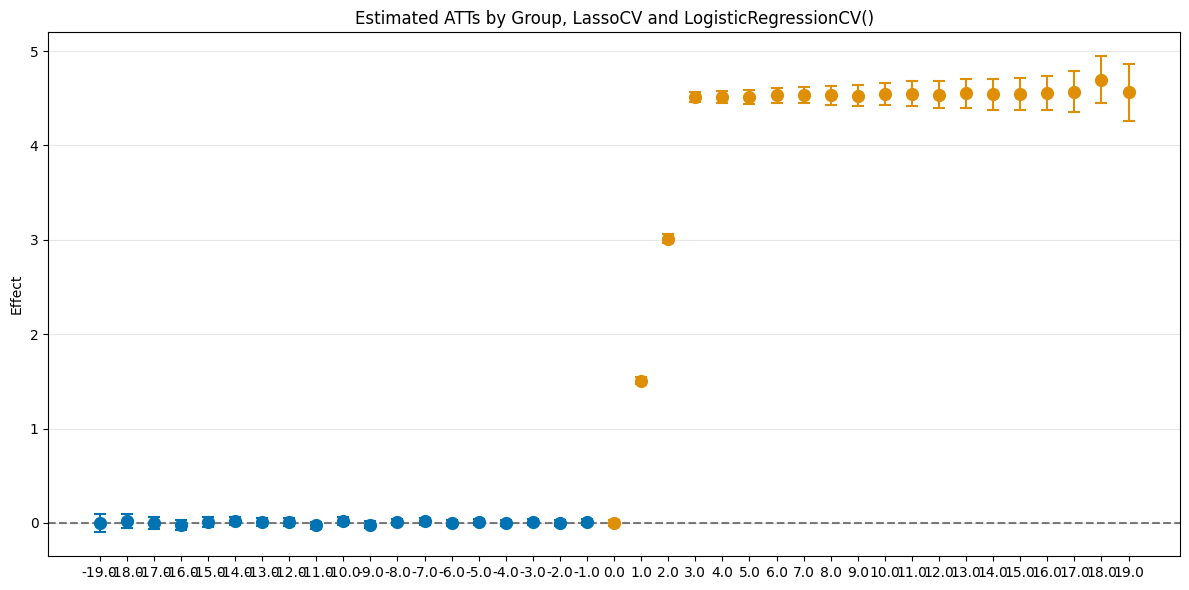

In [39]:
es_rf = dml_obj_lasso.aggregate("eventstudy")
es_rf.aggregated_frameworks.bootstrap()
es_rf.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")

### Spatially-Disentangled Doubly Robust Machine Learning for Policy Evaluation

Vamos separar a análise em duas partes:
* Parte 1: Estimativa do efeito do tratamento direto: Tratados e nunão tratados (excluindo vizinhos)
  * $\text{ATT}^{\text{direto}}$
* Parte 2: Estimativa do efeito do tratamento indireto: Vizinhos dos tratados e Nunca tratados (excluindo tratados)
  * $\text{ATT}^{\text{indireto}}$

Separando a base de dados em duas partes, uma para cada estimativa.

In [149]:
panel_de

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
25,1718451,Pugmil,TO,-0.138264,-0.979926,0.342451,-10.422515,-48.882359,2000,NaN,...,9.966838,0.0,0,NaN,NaN,0,0,1,NaN,NaN
26,1718451,Pugmil,TO,-0.132444,-0.961857,0.357684,-10.422515,-48.882359,2001,NaN,...,9.612030,0.0,0,NaN,NaN,0,0,1,NaN,NaN
27,1718451,Pugmil,TO,-0.126624,-0.943788,0.372916,-10.422515,-48.882359,2002,NaN,...,10.093803,0.0,0,NaN,NaN,0,0,1,NaN,NaN
28,1718451,Pugmil,TO,-0.120803,-0.925718,0.388149,-10.422515,-48.882359,2003,NaN,...,9.824669,0.0,0,NaN,NaN,0,0,1,NaN,NaN
29,1718451,Pugmil,TO,-0.114983,-0.907649,0.403381,-10.422515,-48.882359,2004,NaN,...,9.941119,0.0,0,NaN,NaN,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


In [150]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,NaN,...,28.078476,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,NaN,...,27.913217,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,NaN,...,28.174238,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,NaN,...,28.462075,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,NaN,...,27.960155,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


#### Efeito do Tratamento Direto

In [151]:
panel_de.loc[panel_de['g_treated'] == 0, 'g_treated'] = np.inf

panel_de['g_treated'] = panel_de['g_treated'].astype(float)
panel_de['year'] = panel_de['year'].astype(int)

panel_de['g_treated'] = panel_de['g_treated'].fillna(np.inf)

panel_de = panel_de.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [152]:
# Direct Effect (DE) Data
dml_data_DE = DoubleMLPanelData(
    data=panel_de,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)
print(dml_data_DE)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['g_treated']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 3298

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82450 entries, 0 to 82449
Columns: 28 entries, codmun to g_neighbor
dtypes: float64(19), int64(6), object(3)
memory usage: 17.6+ MB



In [153]:
dml_obj_DE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_DE,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_DE.fit()
print(dml_obj_DE.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001) -0.0716   0.0735  -0.9750  0.3296 -0.2156  0.0724
ATT(2005.0,2001,2002)  0.1567   0.0789   1.9869  0.0469  0.0021  0.3113
ATT(2005.0,2002,2003) -0.1793   0.0758  -2.3662  0.0180 -0.3278 -0.0308
ATT(2005.0,2003,2004)  0.0634   0.0871   0.7274  0.4670 -0.1074  0.2341
ATT(2005.0,2004,2005)  0.1765   0.0690   2.5587  0.0105  0.0413  0.3118
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.0292   0.0633   0.4608  0.6449 -0.0950  0.1533
ATT(2020.0,2019,2021)  1.5565   0.0635  24.5209  0.0000  1.4321  1.6809
ATT(2020.0,2019,2022)  3.1367   0.0607  51.7103  0.0000  3.0178  3.2556
ATT(2020.0,2019,2023)  4.4861   0.0495  90.6909  0.0000  4.3892  4.5831
ATT(2020.0,2019,2024)  4.6223   0.0641  72.1497  0.0000  4.4967  4.7478

[384 rows x 6 columns]


In [154]:
level = 0.95

ci = dml_obj_DE.confint(level=level)
dml_obj_DE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_DE.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.349530  0.206288
ATT(2005.0,2001,2002) -0.141662  0.455059
ATT(2005.0,2002,2003) -0.465942  0.107359
ATT(2005.0,2003,2004) -0.266165  0.392875
ATT(2005.0,2004,2005) -0.084478  0.437562
...                         ...       ...
ATT(2020.0,2019,2020) -0.210431  0.268806
ATT(2020.0,2019,2021)  1.316364  1.796640
ATT(2020.0,2019,2022)  2.907195  3.366149
ATT(2020.0,2019,2023)  4.298996  4.673267
ATT(2020.0,2019,2024)  4.379906  4.864635

[384 rows x 2 columns]


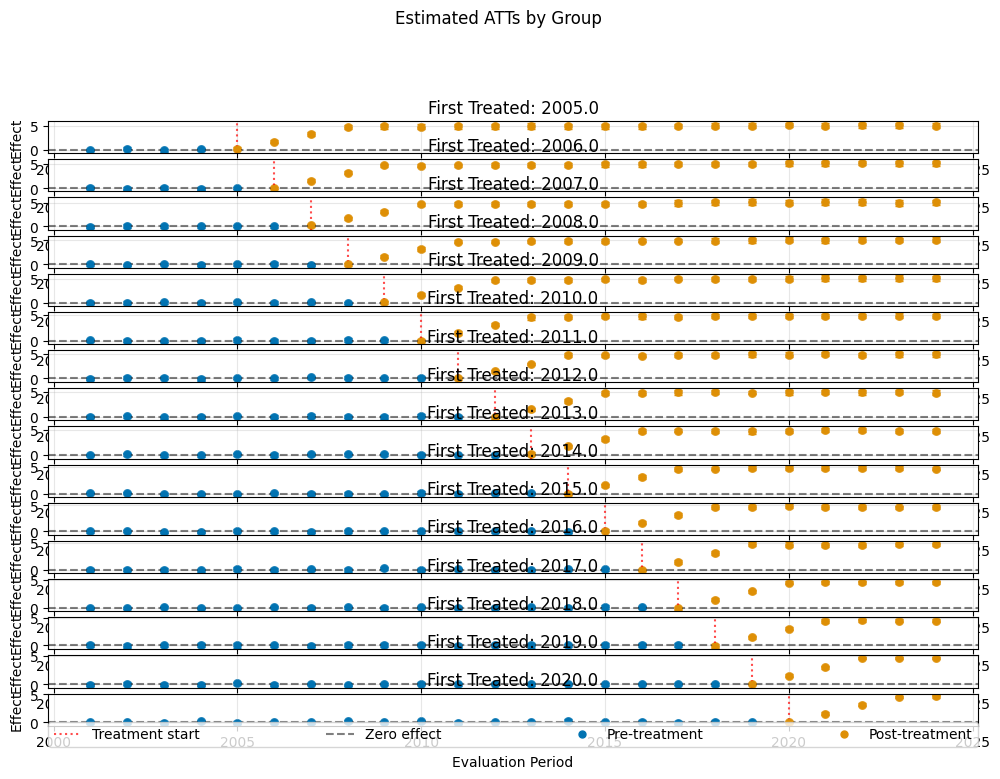

In [155]:
fig, ax = dml_obj_DE.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
   coef  std err          t  P>|t|    2.5 %   97.5 %
4.38241 0.031381 139.650785    0.0 4.320904 4.443916
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.049431  0.070838   -0.697809  0.485297 -0.188271  0.089408
-18.0 -0.029888  0.050363   -0.593460  0.552874 -0.128597  0.068821
-17.0  0.014471  0.039456    0.366767  0.713792 -0.062860  0.091802
-16.0  0.002802  0.032920    0.085119  0.932167 -0.061719  0.067323
-15.0 -0.030867  0.028123   -1.097573  0.272391 -0.085987  0.024253
-14.0  0.058192  0.028572    2.036683  0.041682  0.002192  0.114192
-13.0  0.005741  0.026898    0.213429  0.830992 -0.046978  0.058460
-12.0  0.009373  0.022436    0.417756  0.676126 -0.034601  0.053347
-11.0  0.015395  0.023807    0.646656  0.517855 -0.031266

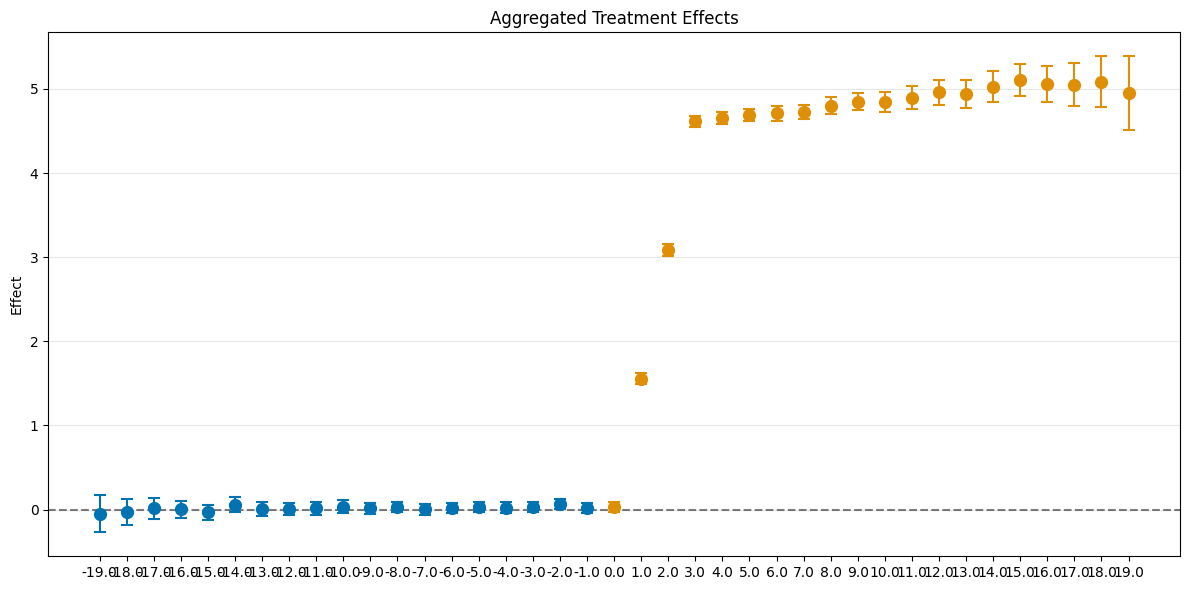

In [156]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_DE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_DE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_DE)
fig, ax = aggregated_eventstudy_DE.plot_effects()

#### Efeito do Tratamento Indireto

In [157]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,NaN,...,28.078476,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,NaN,...,27.913217,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,NaN,...,28.174238,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,NaN,...,28.462075,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,NaN,...,27.960155,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


In [158]:
panel_id.loc[panel_id['g_neighbor'] == 0, 'g_neighbor'] = np.inf

panel_id['g_neighbor'] = panel_id['g_neighbor'].astype(float)
panel_id['year'] = panel_id['year'].astype(int)

panel_id['g_neighbor'] = panel_id['g_neighbor'].fillna(np.inf)

panel_id = panel_id.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [159]:
# Indirect Effect (IE) Data
dml_data_IE = DoubleMLPanelData(
    data=panel_id,
    y_col="Y",
    d_cols="g_neighbor",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)

In [160]:
dml_obj_IE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_IE,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_IE.fit()
print(dml_obj_IE.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.0118   0.0371   0.3165  0.7516 -0.0610  0.0846
ATT(2005.0,2001,2002)  0.0163   0.0375   0.4340  0.6643 -0.0572  0.0897
ATT(2005.0,2002,2003) -0.0404   0.0409  -0.9883  0.3230 -0.1206  0.0397
ATT(2005.0,2003,2004)  0.0165   0.0390   0.4243  0.6713 -0.0598  0.0929
ATT(2005.0,2004,2005)  0.6001   0.0360  16.6492  0.0000  0.5295  0.6707
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.5805   0.0413  14.0624  0.0000  0.4996  0.6614
ATT(2020.0,2019,2021)  0.6141   0.0411  14.9376  0.0000  0.5335  0.6947
ATT(2020.0,2019,2022)  0.5774   0.0413  13.9781  0.0000  0.4964  0.6583
ATT(2020.0,2019,2023)  0.6335   0.0409  15.4735  0.0000  0.5533  0.7138
ATT(2020.0,2019,2024)  0.5889   0.0374  15.7350  0.0000  0.5156  0.6623

[384 rows x 6 columns]


In [161]:
level = 0.95

ci = dml_obj_IE.confint(level=level)
dml_obj_IE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_IE.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.128414  0.151930
ATT(2005.0,2001,2002) -0.125193  0.157730
ATT(2005.0,2002,2003) -0.194787  0.113936
ATT(2005.0,2003,2004) -0.130481  0.163543
ATT(2005.0,2004,2005)  0.464077  0.736113
...                         ...       ...
ATT(2020.0,2019,2020)  0.424736  0.736309
ATT(2020.0,2019,2021)  0.458955  0.769234
ATT(2020.0,2019,2022)  0.421497  0.733247
ATT(2020.0,2019,2023)  0.479028  0.788043
ATT(2020.0,2019,2024)  0.447680  0.730162

[384 rows x 2 columns]


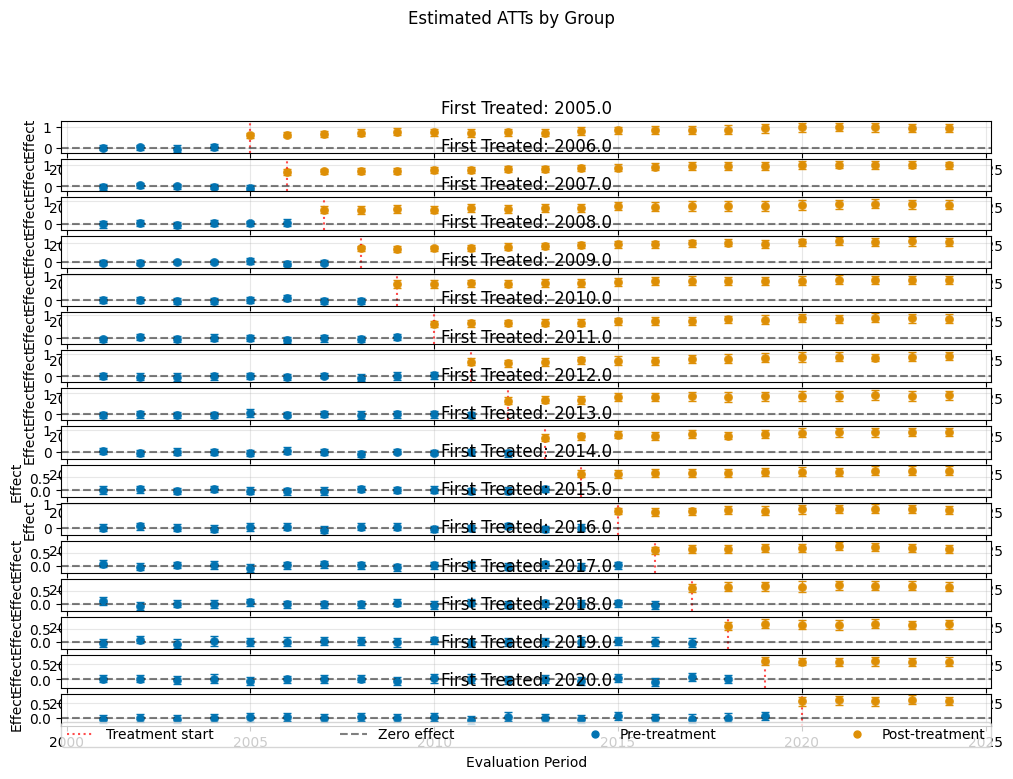

In [163]:
fig, ax = dml_obj_IE.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err        t  P>|t|    2.5 %   97.5 %
0.822553 0.012696 64.78662    0.0 0.797668 0.847437
------------------ Aggregated Effects         ------------------
           coef   std err          t     P>|t|     2.5 %    97.5 %
-19.0 -0.037505  0.038192  -0.982014  0.326093 -0.112359  0.037349
-18.0  0.004561  0.023863   0.191116  0.848434 -0.042210  0.051331
-17.0 -0.009720  0.021115  -0.460329  0.645280 -0.051104  0.031665
-16.0  0.025874  0.018952   1.365270  0.172168 -0.011271  0.063019
-15.0 -0.003821  0.016912  -0.225931  0.821255 -0.036968  0.029326
-14.0 -0.010855  0.015235  -0.712467  0.476176 -0.040715  0.019006
-13.0  0.005737  0.014188   0.404352  0.685954 -0.022071  0.033545
-12.0  0.025995  0.012745   2.039634  0.041387  0.001015  0.050974
-11.0 -0.022812  0.011936  -1.911285  0.055968 -0.046205  0.000581
-

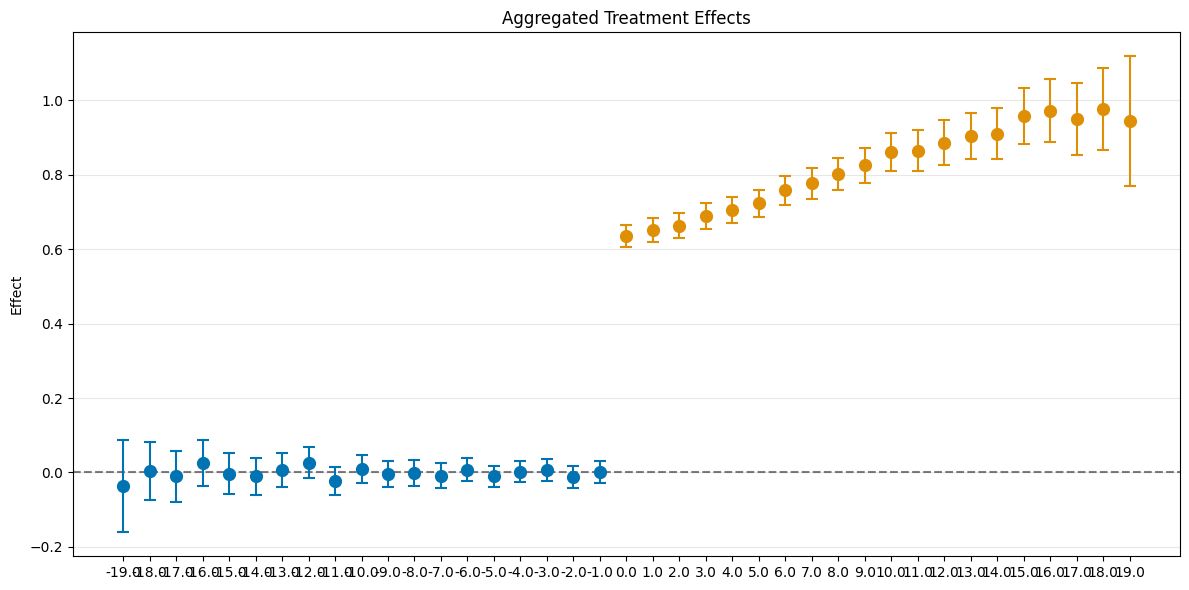

In [164]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_IE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_IE = dml_obj_IE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_IE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_IE)
fig, ax = aggregated_eventstudy_IE.plot_effects()

Efeito Direto Heterogêneo (ATT)
Estimativa do efeito do tratamento sobre os próprios tratados:

𝐴
𝑇
𝑇
𝑔
𝑡
=
𝐸
[
𝑌
𝑖
𝑡
(
1
)
−
𝑌
𝑖
𝑡
(
0
)
∣
𝐺
𝑖
=
𝑔
,
𝑇
=
𝑡
]
ATT 
gt
​
 =E[Y 
it
​
 (1)−Y 
it
​
 (0)∣G 
i
​
 =g,T=t]
A ser estimado com:

Callaway & Sant’Anna (2021) + DoubleML (para controle flexível)

Apenas municípios tratados diretamente

Comparados com nunca tratados ou ainda não tratados

Excluindo os vizinhos dos tratados para evitar contaminação por spillover

 Efeito Indireto Heterogêneo (Spillover)
Estimativa do efeito médio sobre municípios não tratados que são vizinhos de tratados:

𝐴
𝑇
𝑇
𝑔
𝑡
𝑠
𝑝
𝑖
𝑙
𝑙
𝑜
𝑣
𝑒
𝑟
=
𝐸
[
𝑌
𝑖
𝑡
∣
𝐷
𝑖
𝑡
=
0
,
𝑊
𝐷
𝑖
𝑡
>
0
]
−
𝐸
[
𝑌
𝑖
𝑡
∣
𝐷
𝑖
𝑡
=
0
,
𝑊
𝐷
𝑖
𝑡
=
0
]
ATT 
gt
spillover
​
 =E[Y 
it
​
 ∣D 
it
​
 =0,WD 
it
​
 >0]−E[Y 
it
​
 ∣D 
it
​
 =0,WD 
it
​
 =0]
A ser estimado com:

Diferença entre unidades não tratadas, comparando:

As que têm vizinhos tratados (W D_{it} > 0)

E as que não têm (W D_{it} = 0)

Também com controle via Machine Learning

Também com base em diferenças em diferenças (diferença relativa ao pré-tratamento)

#### Spatial Doubly Robust Machine Learning (SDRML)

Vamos tentar desagregar o efeito médio do tratamento em dois componentes:
- Efeito médio do tratamento heterogêneo direto

$$ ATT_{gt} = E[Y_{it} | D_{it} = 1] - E[Y_{it} | D_{it} = 0] $$

- Efeito médio do tratamento heterogêneo indireto (spillover)

$$ ATT_{gt}^{spillover} = E[Y_{it} | D_{it} = 0, W D_{it} > 0] - E[Y_{it} | D_{it} = 0, W D_{it} = 0] $$

A ideia é utilizar o estimador de Callaway e SantAnna com Double Machine Learning para estimar o efeito médio do tratamento heterogêneo direto (municípios tratados), excluindo os vizinhos dos tratados, e comparando-os com os nunca tratados ou ainda não tratados. Depois fazer a mesma coisa para o efeito médio do tratamento heterogêneo indireto (spillover), comparando-os com os nunca tratados ou ainda não tratados. Isso dentro do arcabouço de dupla robustez de Callaway e Sant'Anna (2021) e com a flexibilidade das funções do Machine Learning.



e indireto, considerando a vizinhança espacial.

In [53]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV

from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti


In [73]:
# D = 1 se o município já foi tratado naquele ano ou depois, e 0 caso contrário
panel["D"] = ((panel["year"] >= panel["treat_year"]) & (panel["treat_year"] > 0)).astype(int)


In [74]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDID
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# Criar o objeto DoubleMLPanelData com a base limpa e corrigida
data_dml = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
    t_col='year',
    id_col='codmun'
)

# Instanciar e ajustar o estimador
dml_did = DoubleMLDID(
    data_dml,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

dml_did.fit()

# Ver resultado
print(dml_did.summary)



ValueError: Found input variables with inconsistent numbers of samples: [5573, 139325]

In [68]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# Garantir que o tempo seja inteiro
panel['year'] = panel['year'].astype(int)

# Criar o objeto DoubleMLPanelData
data = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
    t_col='year',
    id_col='codmun'
)

# Instanciar corretamente o estimador (sem nomes nos argumentos)
dml_did_cs = DoubleMLDIDCS(
    data,
    LassoCV(cv=5),
    LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# Estimar
dml_did_cs.fit()

# Resultado
print(dml_did_cs.summary)


ValueError: Incompatible data. To fit an DIDCS model with DML exactly one binary variable with values 0 and 1 needs to be specified as time variable.

In [67]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# 1. Carregando os dados simulados (ajustar nomes se necessário)
panel['year'] = panel['year'].astype(int)

# 2. Criar objeto DoubleMLPanelData corretamente
# Aqui você já passa todas as variáveis necessárias
data = DoubleMLPanelData(
    data=panel,
    y_col='Y',         # variável dependente
    d_cols='D',         # tratamento (1 tratado, 0 não tratado)
    x_cols=['X1', 'X2', 'X3'],  # covariáveis
    t_col='year',      # variável de tempo
    id_col='codmun'  # identificador do painel
)

# 3. Instanciar o estimador corretamente, sem repetir y_col etc.
dml_did_cs = DoubleMLDIDCS(
    data=data,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'  # ou 'ATE' se preferir
)

# 4. Rodar a estimação
dml_did_cs.fit()

# 5. Ver resultados
print(dml_did_cs.summary)


TypeError: DoubleMLDIDCS.__init__() got an unexpected keyword argument 'data'

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS

# 2. Garante que 'year' é inteiro
panel['year'] = panel['year'].astype(int)

# 3. Criação do objeto DoubleMLPanelData (seguindo o exemplo do site)
data = DoubleMLPanelData(
    data=panel,
    t_col='year',
    id_col='codmun',
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
)

# 4. Instancia o estimador DoubleMLDIDCS (Cross-Section DiD)
dml_did_cs = DoubleMLDIDCS(
    data,
    y_col='Y',
    d_col='D',
    x_cols=['X1', 'X2', 'X3'],
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# 5. Estima o modelo
dml_did_cs.fit()

# 6. Resultado
print(dml_did_cs.summary)



TypeError: DoubleMLDIDCS.__init__() got an unexpected keyword argument 'y_col'

In [54]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

# --------------------------------------------------
# 1. Preparar os dados
# --------------------------------------------------
# Certifique-se de que 'codmun' e 'year' sejam do tipo adequado
panel['codmun'] = panel['codmun'].astype(str)
panel['year'] = panel['year'].astype(int)

# --------------------------------------------------
# 2. Criar objeto DoubleMLPanelData
# --------------------------------------------------
dml_data = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_col='D',
    x_cols=['X1', 'X2', 'X3'],
    time_col='year',
    cluster_cols='codmun',
    unit_col='codmun'
)

# --------------------------------------------------
# 3. Estimador DoubleMLDIDMulti (DID com várias coortes)
# --------------------------------------------------
dml_did = DoubleMLDIDMulti(
    data=dml_data,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# --------------------------------------------------
# 4. Ajustar o modelo
# --------------------------------------------------
dml_did.fit()

# --------------------------------------------------
# 5. Ver resultados
# --------------------------------------------------
print(dml_did.summary)


TypeError: DoubleMLPanelData.__init__() got an unexpected keyword argument 'd_col'

In [ ]:
from doubleml import DoubleMLPanelData


dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="D",            # sua variável de tratamento (0/1)
    id_col="codmun",
    t_col="year",
    x_cols=["X1", "X2", "X3"]  # covariáveis preditoras
)

ImportError: cannot import name 'DoubleMLPanelData' from 'doubleml' (c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\doubleml\__init__.py)

In [48]:
import doubleml as dml
print(dml.__version__)


0.10.0


### Estimador para Callaway e Sant'Anna (2021)

**ideia geral**

A ideia aqui é partir do estimador de Sant'Anna e Zhao (2020) e adaptá-lo para o caso de múltiplos períodos de tratamento, como proposto por Callaway e Sant'Anna (2021). Vamos utilizar o pacote em python do DoubleML para implementar o estimador. E compará-lo com o estimador `differences` do python.

**Objetivo do Projeto**

* Implementar o estimador de Callaway & Sant’Anna (2021) para múltiplos períodos de tratamento, adaptando o DoubleML (que já possui o estimador de Sant'Anna & Zhao, 2020).
* Comparar os resultados com o estimador differences disponível no Python.
* Analisar consistência, precisão, robustez e desempenho computacional dos dois 


!pip install differences
!pip install doubleml

In [3]:
import pandas as pd
import numpy as np

data = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/bacon_example.dta")

In [4]:
# Filtragem dos dados
# Vamos criar identificadores estaduais
data['id'] = data['stfips'].rank(method='dense').astype(int)

# time to treat
data['t'] = data['year'] - data['_nfd']

# Outcome (Suicide Mortality)
data['y'] = data['asmrs']

# Covariáveis - pcinc asmrh cases
data['X1'] = data['pcinc']
data['X2'] = data['asmrh']
data['X3'] = data['cases']

# Treatment
data['D'] = data['post']
data['media_D'] = data.groupby('id')['D'].transform('mean')
data['always_treated'] = np.where(data['media_D'] == 1, 1, 0)
data['never_treated'] = np.where(data['media_D'] == 0, 1, 0)
# foi tratado em algum momento media_D for maior que 0, será um valor 1 para o id
data['treated'] = np.where(data['media_D'] > 0, 1, 0)

# Vamos criar a variável de grupo G
data['cohort']=data['_nfd']

In [ ]:
print(sorted(data['t'].unique()))

[-21.0, -20.0, -19.0, -18.0, -17.0, -16.0, -15.0, -14.0, -13.0, -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, nan, 26.0, 27.0]


In [6]:
data

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
0,1,1964.0,1971.0,0.0,35.639885,12406.178537,5.007341,0.012312,1.715156e+06,1.715156e+06,...,35.639885,12406.178537,5.007341,0.012312,0.0,0.787879,0,0,1,1971.0
1,1,1965.0,1971.0,0.0,41.543755,13070.206738,4.425367,0.010419,1.715156e+06,1.725186e+06,...,41.543755,13070.206738,4.425367,0.010419,0.0,0.787879,0,0,1,1971.0
2,1,1966.0,1971.0,0.0,34.252335,13526.663217,4.874819,0.009900,1.715156e+06,1.735219e+06,...,34.252335,13526.663217,4.874819,0.009900,0.0,0.787879,0,0,1,1971.0
3,1,1967.0,1971.0,0.0,34.465023,13918.189823,5.362014,0.009975,1.715156e+06,1.745250e+06,...,34.465023,13918.189823,5.362014,0.009975,0.0,0.787879,0,0,1,1971.0
4,1,1968.0,1971.0,0.0,40.440105,14684.808682,4.643759,0.012401,1.715156e+06,1.755283e+06,...,40.440105,14684.808682,4.643759,0.012401,0.0,0.787879,0,0,1,1971.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,56,1992.0,1977.0,1.0,33.149574,31181.450546,1.970134,0.028996,1.621688e+05,2.323830e+05,...,33.149574,31181.450546,1.970134,0.028996,1.0,0.606061,0,0,1,1977.0
1613,56,1993.0,1977.0,1.0,63.909775,31666.776231,3.020953,0.026672,1.621688e+05,2.355600e+05,...,63.909775,31666.776231,3.020953,0.026672,1.0,0.606061,0,0,1,1977.0
1614,56,1994.0,1977.0,1.0,81.793816,31959.528356,3.501871,0.023643,1.621688e+05,2.389800e+05,...,81.793816,31959.528356,3.501871,0.023643,1.0,0.606061,0,0,1,1977.0
1615,56,1995.0,1977.0,1.0,30.630585,32327.659531,0.740606,0.020965,1.621688e+05,2.414090e+05,...,30.630585,32327.659531,0.740606,0.020965,1.0,0.606061,0,0,1,1977.0


In [7]:
data['cohort'].describe()

count    1188.000000
mean     1973.583333
std         3.539969
min      1969.000000
25%      1971.000000
50%      1973.000000
75%      1974.250000
max      1985.000000
Name: cohort, dtype: float64

In [8]:
# Criar uma base de dados com apenas um grupo tratado específico e todos os nunca tratados.
data_sz = data[(data['cohort'] == 1973) | (data['never_treated'] == 1)]

In [9]:
data_sz

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
33,4,1964.0,1973.0,0.0,73.528717,15551.315938,3.083218,0.012883,744813.0,7.448130e+05,...,73.528717,15551.315938,3.083218,0.012883,0.0,0.727273,0,0,1,1973.0
34,4,1965.0,1973.0,0.0,82.431198,15962.689260,3.005868,0.012225,744813.0,7.692093e+05,...,82.431198,15962.689260,3.005868,0.012225,0.0,0.727273,0,0,1,1973.0
35,4,1966.0,1973.0,0.0,59.255363,16581.270102,5.074290,0.012180,744813.0,7.936050e+05,...,59.255363,16581.270102,5.074290,0.012180,0.0,0.727273,0,0,1,1973.0
36,4,1967.0,1973.0,0.0,81.493416,17214.603202,3.836898,0.012327,744813.0,8.180007e+05,...,81.493416,17214.603202,3.836898,0.012327,0.0,0.727273,0,0,1,1973.0
37,4,1968.0,1973.0,0.0,72.936737,18610.393366,5.394385,0.012178,744813.0,8.423957e+05,...,72.936737,18610.393366,5.394385,0.012178,0.0,0.727273,0,0,1,1973.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,53,1992.0,1973.0,1.0,50.471672,35482.948403,3.107361,0.037566,1546064.0,2.598309e+06,...,50.471672,35482.948403,3.107361,0.037566,1.0,0.727273,0,0,1,1973.0
1514,53,1993.0,1973.0,1.0,47.067001,35571.542235,2.844220,0.038398,1546064.0,2.656901e+06,...,47.067001,35571.542235,2.844220,0.038398,1.0,0.727273,0,0,1,1973.0
1515,53,1994.0,1973.0,1.0,45.564236,35987.602571,3.035455,0.038123,1546064.0,2.705420e+06,...,45.564236,35987.602571,3.035455,0.038123,1.0,0.727273,0,0,1,1973.0
1516,53,1995.0,1973.0,1.0,45.268627,36422.286961,3.326494,0.036635,1546064.0,2.756447e+06,...,45.268627,36422.286961,3.326494,0.036635,1.0,0.727273,0,0,1,1973.0


#### Aplicar DoubleML-DID



Analisar a dupla diferença para os períodos t=-1 e t=1.

In [11]:
# 1. Manter na base apenas t == -1, t == 1 ou t == NA
data_sz_1 = data_sz[(data_sz['t'].isin([-1.0, 1.0])) | (data_sz['t'].isna())]

# 2. Identificar anos dos tratados
anos_tratados = data_sz_1[data_sz_1['never_treated'] == 0]['year'].unique()

# 3. Filtrar: manter tratados ou never_treated com anos dos tratados
data_sz_1 = data_sz_1[(data_sz_1['never_treated'] == 0) | ((data_sz_1['never_treated'] == 1) & (data_sz_1['year'].isin(anos_tratados)))]
data_sz_1

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,101.922516,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0
43,4,1974.0,1973.0,1.0,87.002365,23114.632475,4.767786,0.018148,7.448130e+05,1125678.0,...,87.002365,23114.632475,4.767786,0.018148,1.0,0.727273,0,0,1,1973.0
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,56.250359,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN
76,5,1974.0,NaN,0.0,48.406815,18717.644793,4.108365,0.026070,9.379597e+05,1080970.0,...,48.406815,18717.644793,4.108365,0.026070,0.0,0.000000,0,1,0,NaN
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,47.559387,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0
175,9,1974.0,1973.0,1.0,38.020470,28855.494139,2.411515,0.023150,1.407318e+06,1586262.0,...,38.020470,28855.494139,2.411515,0.023150,1.0,0.727273,0,0,1,1973.0
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,47.521610,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN
208,10,1974.0,NaN,0.0,56.700481,27049.663476,5.338567,0.030429,2.475022e+05,299688.0,...,56.700481,27049.663476,5.338567,0.030429,0.0,0.000000,0,1,0,NaN
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,67.377106,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0
307,13,1974.0,1973.0,1.0,64.986893,21006.430168,9.746268,0.041766,2.150928e+06,2576772.0,...,64.986893,21006.430168,9.746268,0.041766,1.0,0.727273,0,0,1,1973.0


Fazer o procedimento para utilizar o DML

In [12]:
# criar uma variável de diferença de y na base data_sz_1['y_diff'] 
data_sz_1['y_diff'] = data_sz_1.groupby('id')['y'].diff()

# substituir valores data_sz_1['y_diff'] "na" pelo valor da y_diff do id calculado para o período posterior
data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')


C:\Users\danie\AppData\Local\Temp\ipykernel_15180\1607195728.py:5: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')
C:\Users\danie\AppData\Local\Temp\ipykernel_15180\1607195728.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')


In [13]:
data_sz_1

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort,y_diff
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0,-14.920151
43,4,1974.0,1973.0,1.0,87.002365,23114.632475,4.767786,0.018148,7.448130e+05,1125678.0,...,23114.632475,4.767786,0.018148,1.0,0.727273,0,0,1,1973.0,-14.920151
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN,-7.843544
76,5,1974.0,NaN,0.0,48.406815,18717.644793,4.108365,0.026070,9.379597e+05,1080970.0,...,18717.644793,4.108365,0.026070,0.0,0.000000,0,1,0,NaN,-7.843544
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0,-9.538918
175,9,1974.0,1973.0,1.0,38.020470,28855.494139,2.411515,0.023150,1.407318e+06,1586262.0,...,28855.494139,2.411515,0.023150,1.0,0.727273,0,0,1,1973.0,-9.538918
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN,9.178871
208,10,1974.0,NaN,0.0,56.700481,27049.663476,5.338567,0.030429,2.475022e+05,299688.0,...,27049.663476,5.338567,0.030429,0.0,0.000000,0,1,0,NaN,9.178871
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0,-2.390213
307,13,1974.0,1973.0,1.0,64.986893,21006.430168,9.746268,0.041766,2.150928e+06,2576772.0,...,21006.430168,9.746268,0.041766,1.0,0.727273,0,0,1,1973.0,-2.390213


In [14]:
df_dml = data_sz_1[data_sz_1['year'] == data_sz_1['year'].min()].copy()
df_dml

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort,y_diff
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0,-14.920151
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN,-7.843544
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0,-9.538918
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN,9.178871
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0,-2.390213
404,18,1972.0,1973.0,0.0,56.968685,22011.952470,2.517947,0.017422,2.490114e+06,2711777.0,...,22011.952470,2.517947,0.017422,0.0,0.727273,0,0,1,1973.0,-5.073200
569,23,1972.0,1973.0,0.0,46.754639,19694.904842,3.060293,0.034757,4.958082e+05,529513.0,...,19694.904842,3.060293,0.034757,0.0,0.727273,0,0,1,1973.0,16.283157
734,28,1972.0,NaN,0.0,43.245850,16283.150389,6.472214,0.037212,1.118302e+06,1186875.0,...,16283.150389,6.472214,0.037212,0.0,0.000000,0,1,0,NaN,0.141403
767,29,1972.0,1973.0,0.0,58.237740,22350.673416,3.024333,0.026119,2.298065e+06,2459347.0,...,22350.673416,3.024333,0.026119,0.0,0.727273,0,0,1,1973.0,1.111126
866,32,1972.0,1973.0,0.0,111.368187,28388.742447,5.085210,0.017197,1.795353e+05,269158.0,...,28388.742447,5.085210,0.017197,0.0,0.727273,0,0,1,1973.0,49.472572


In [71]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from doubleml import DoubleMLDID
import numpy as np
from doubleml import DoubleMLData

np.random.seed(1)

dml_data = DoubleMLData.from_arrays(
    x= df_dml[['X1', 'X2', 'X3']],
    y=df_dml['y_diff'],
    d=df_dml['treated']
)

ml_g = LinearRegression()
ml_m = LogisticRegression()

dml_did1 = DoubleMLDID(
    dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='observational',
    n_folds=2
)

dml_did1.fit()
print(dml_did1.summary)
print("Intervalo de confiança 95%:")
print(dml_did1.confint(level=0.95))


       coef    std err         t     P>|t|      2.5 %     97.5 %
d  4.522434  21.074514  0.214593  0.830085 -36.782854  45.827722
Intervalo de confiança 95%:
       2.5 %     97.5 %
d -36.782854  45.827722


c:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from doubleml import DoubleMLDID
import numpy as np
from doubleml import DoubleMLData

np.random.seed(1)

dml_data = DoubleMLData.from_arrays(
    x= df_dml[['X1', 'X2', 'X3']],
    y=df_dml['y_diff'],
    d=df_dml['treated']
)

ml_g = RandomForestRegressor()
ml_m = RandomForestClassifier()

dml_did2 = DoubleMLDID(
    dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='observational',
    n_folds=2
)

dml_did2.fit()
print(dml_did2.summary)
print("Intervalo de confiança 95%:")
print(dml_did2.confint(level=0.95))

       coef   std err         t     P>|t|      2.5 %     97.5 %
d -1.959208  7.337674 -0.267007  0.789464 -16.340785  12.422369
Intervalo de confiança 95%:
       2.5 %     97.5 %
d -16.340785  12.422369


In [83]:
data_sz_1

stfips    year    _nfd  post       asmrs         pcinc     asmrh  \
id1 year1                                                                     
2   1972        4  1972.0  1973.0   0.0  101.922516  22979.025315  3.912483   
    1974        4  1974.0  1973.0   1.0   87.002365  23114.632475  4.767786   
3   1972        5  1972.0     NaN   0.0   56.250359  17225.678238  4.724695   
    1974        5  1974.0     NaN   0.0   48.406815  18717.644793  4.108365   
6   1972        9  1972.0  1973.0   0.0   47.559387  28467.286435  1.722194   
    1974        9  1974.0  1973.0   1.0   38.020470  28855.494139  2.411515   
7   1972       10  1972.0     NaN   0.0   47.521610  26803.135702  1.417574   
    1974       10  1974.0     NaN   0.0   56.700481  27049.663476  5.338567   
10  1972       13  1972.0  1973.0   0.0   67.377106  20588.342698  7.584846   
    1974       13  1974.0  1973.0   1.0   64.986893  21006.430168  9.746268   
13  1972       18  1972.0  1973.0   0.0   56.968685  22011.952470  2.517947   
    1974       18  1974.0  1973.0   1.0   51.895485  22875.254923  3.930914   
18  1972       23  1972.0  1973.0   0.0   46.754639  19694.904842  3.060293   
    1974       23  1974.0  1973.0   1.0   63.037796  20510.876637  2.174452   
23  1972       28  1972.0     NaN   0.0   43.245850  16283.150389  6.472214   
    1974       28  1974.0     NaN   0.0   43.387253  16966.409012  6.367793   
24  1972       29  1972.0  1973.0   0.0   58.237740  22350.673416  3.024333   
    1974       29  1974.0  1973.0   1.0   59.348866  22577.082883  2.947727   
27  1972       32  1972.0  1973.0   0.0  111.368187  28388.742447  5.085210   
    1974       32  1974.0  1973.0   1.0  160.840759  27944.179595  8.146376   
30  1972       35  1972.0  1973.0   0.0   51.931870  19685.086843  5.733760   
    1974       35  1974.0  1973.0   1.0   69.617287  20216.904204  3.798809   
31  1972       36  1972.0     NaN   0.0   37.546421  27583.666577  3.493527   
    1974       36  1974.0     NaN   0.0   35.241112  27436.027246  3.842149   
36  1972       41  1972.0  1973.0   0.0   84.219421  23327.564259  2.915845   
    1974       41  1974.0  1973.0   1.0   75.755478  24529.899762  2.952571   
41  1972       47  1972.0     NaN   0.0   50.976021  19164.732927  5.394639   
    1974       47  1974.0     NaN   0.0   59.248425  20036.321137  4.638008   
46  1972       53  1972.0  1973.0   0.0   84.728195  24196.457120  1.711642   
    1974       53  1974.0  1973.0   1.0   82.237000  25684.791464  2.639225   

              cases        weight      copop  ...            X1        X2  \
id1 year1                                     ...                           
2   1972   0.018428  7.448130e+05  1017302.0  ...  22979.025315  3.912483   
    1974   0.018148  7.448130e+05  1125678.0  ...  23114.632475  4.767786   
3   1972   0.020913  9.379597e+05  1038165.0  ...  17225.678238  4.724695   
    1974   0.026070  9.379597e+05  1080970.0  ...  18717.644793  4.108365   
6   1972   0.020316  1.407318e+06  1580484.0  ...  28467.286435  1.722194   
    1974   0.023150  1.407318e+06  1586262.0  ...  28855.494139  2.411515   
7   1972   0.030777  2.475022e+05   294246.0  ...  26803.135702  1.417574   
    1974   0.030429  2.475022e+05   299688.0  ...  27049.663476  5.338567   
10  1972   0.038746  2.150928e+06  2476205.0  ...  20588.342698  7.584846   
    1974   0.041766  2.150928e+06  2576772.0  ...  21006.430168  9.746268   
13  1972   0.017422  2.490114e+06  2711777.0  ...  22011.952470  2.517947   
    1974   0.018639  2.490114e+06  2741821.0  ...  22875.254923  3.930914   
18  1972   0.034757  4.958082e+05   529513.0  ...  19694.904842  3.060293   
    1974   0.041076  4.958082e+05   543179.0  ...  20510.876637  2.174452   
23  1972   0.037212  1.118302e+06  1186875.0  ...  16283.150389  6.472214   
    1974   0.042730  1.118302e+06  1225186.0  ...  16966.409012  6.367793   
24  1972   0.026119  2.298065e+06  2459347.0  ...  22350.673416  3.024333   
    1974   0.031987

In [73]:
# O pacote precisa entender a estrutura de painel dos dados. Precisamos ajustar a variável year para int (inteiro)
# Criando clones
data_sz_1['year1'] = data_sz_1['year']
data_sz_1['id1'] = data_sz_1['id']
data_sz_1['year1'] = data_sz_1['year'].astype(int)


data_sz_1.set_index(['id1', 'year1'], inplace=True)


data_sz_1

stfips    year    _nfd  post       asmrs         pcinc     asmrh  \
id1 year1                                                                     
2   1972        4  1972.0  1973.0   0.0  101.922516  22979.025315  3.912483   
    1974        4  1974.0  1973.0   1.0   87.002365  23114.632475  4.767786   
3   1972        5  1972.0     NaN   0.0   56.250359  17225.678238  4.724695   
    1974        5  1974.0     NaN   0.0   48.406815  18717.644793  4.108365   
6   1972        9  1972.0  1973.0   0.0   47.559387  28467.286435  1.722194   
    1974        9  1974.0  1973.0   1.0   38.020470  28855.494139  2.411515   
7   1972       10  1972.0     NaN   0.0   47.521610  26803.135702  1.417574   
    1974       10  1974.0     NaN   0.0   56.700481  27049.663476  5.338567   
10  1972       13  1972.0  1973.0   0.0   67.377106  20588.342698  7.584846   
    1974       13  1974.0  1973.0   1.0   64.986893  21006.430168  9.746268   
13  1972       18  1972.0  1973.0   0.0   56.968685  22011.952470  2.517947   
    1974       18  1974.0  1973.0   1.0   51.895485  22875.254923  3.930914   
18  1972       23  1972.0  1973.0   0.0   46.754639  19694.904842  3.060293   
    1974       23  1974.0  1973.0   1.0   63.037796  20510.876637  2.174452   
23  1972       28  1972.0     NaN   0.0   43.245850  16283.150389  6.472214   
    1974       28  1974.0     NaN   0.0   43.387253  16966.409012  6.367793   
24  1972       29  1972.0  1973.0   0.0   58.237740  22350.673416  3.024333   
    1974       29  1974.0  1973.0   1.0   59.348866  22577.082883  2.947727   
27  1972       32  1972.0  1973.0   0.0  111.368187  28388.742447  5.085210   
    1974       32  1974.0  1973.0   1.0  160.840759  27944.179595  8.146376   
30  1972       35  1972.0  1973.0   0.0   51.931870  19685.086843  5.733760   
    1974       35  1974.0  1973.0   1.0   69.617287  20216.904204  3.798809   
31  1972       36  1972.0     NaN   0.0   37.546421  27583.666577  3.493527   
    1974       36  1974.0     NaN   0.0   35.241112  27436.027246  3.842149   
36  1972       41  1972.0  1973.0   0.0   84.219421  23327.564259  2.915845   
    1974       41  1974.0  1973.0   1.0   75.755478  24529.899762  2.952571   
41  1972       47  1972.0     NaN   0.0   50.976021  19164.732927  5.394639   
    1974       47  1974.0     NaN   0.0   59.248425  20036.321137  4.638008   
46  1972       53  1972.0  1973.0   0.0   84.728195  24196.457120  1.711642   
    1974       53  1974.0  1973.0   1.0   82.237000  25684.791464  2.639225   

              cases        weight      copop  ...            X1        X2  \
id1 year1                                     ...                           
2   1972   0.018428  7.448130e+05  1017302.0  ...  22979.025315  3.912483   
    1974   0.018148  7.448130e+05  1125678.0  ...  23114.632475  4.767786   
3   1972   0.020913  9.379597e+05  1038165.0  ...  17225.678238  4.724695   
    1974   0.026070  9.379597e+05  1080970.0  ...  18717.644793  4.108365   
6   1972   0.020316  1.407318e+06  1580484.0  ...  28467.286435  1.722194   
    1974   0.023150  1.407318e+06  1586262.0  ...  28855.494139  2.411515   
7   1972   0.030777  2.475022e+05   294246.0  ...  26803.135702  1.417574   
    1974   0.030429  2.475022e+05   299688.0  ...  27049.663476  5.338567   
10  1972   0.038746  2.150928e+06  2476205.0  ...  20588.342698  7.584846   
    1974   0.041766  2.150928e+06  2576772.0  ...  21006.430168  9.746268   
13  1972   0.017422  2.490114e+06  2711777.0  ...  22011.952470  2.517947   
    1974   0.018639  2.490114e+06  2741821.0  ...  22875.254923  3.930914   
18  1972   0.034757  4.958082e+05   529513.0  ...  19694.904842  3.060293   
    1974   0.041076  4.958082e+05   543179.0  ...  20510.876637  2.174452   
23  1972   0.037212  1.118302e+06  1186875.0  ...  16283.150389  6.472214   
    1974   0.042730  1.118302e+06  1225186.0  ...  16966.409012  6.367793   
24  1972   0.026119  2.298065e+06  2459347.0  ...  22350.673416  3.024333   
    1974   0.031987

In [79]:
from differences import ATTgt
np.random.seed(1)

att_gt = ATTgt(data=data_sz_1, cohort_name='cohort')

att_gt.fit(formula='y ~ X1 + X2 + X3',  est_method="dr")

print(att_gt.aggregate("simple", overall=True))

Computing ATTgt [workers=1]   100%|████████████████████| 1/1 [00:00<00:00, 92.08it/s]

  SimpleAggregation                                            \
                     analytic pointwise conf. band              
                ATT std_error                lower      upper   
0          3.098641  8.334399            -13.23648  19.433762   

                     
                     
  zero_not_in_cband  
0                    


In [85]:
from differences import ATTgt
np.random.seed(1)

att_gt = ATTgt(data=data_sz_1, cohort_name='cohort')

att_gt.fit(formula='y ~ X1 + X2 + X3',  est_method="reg")

print(att_gt.aggregate("event"))

Computing ATTgt [workers=1]   100%|████████████████████| 1/1 [00:00<00:00, 63.21it/s]

                EventAggregation                                            \
                                  analytic pointwise conf. band              
                             ATT std_error                lower      upper   
relative_period                                                              
1                       3.005559  8.243998           -13.152381  19.163498   

                                   
                                   
                zero_not_in_cband  
relative_period                    
1                                  
